In [3]:
import os, datetime, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import umap
import hdbscan

#  SETTINGS 
SCORES_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\plan scores 1"
OUTPUT_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\Final Files\pipeline_outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

FEATURES = ["Av", "Uv", "Cv", "Ov", "Hv"]
TYPOLOGY_NAMES = ["Wide-Open", "Open", "Semi-Closed", "Closed", "Narrow-Closed"]

# Your exact literature weights
LIT_WEIGHTS = {"Av": 1.0, "Uv": 1.0, "Cv": 0.5, "Ov": -0.6, "Hv": 1.0}
weights_array = np.array([LIT_WEIGHTS[f] for f in FEATURES])

# --- STEP 1: LOAD & CLEAN ---
print("\n--- STEP 1: LOADING DATA ---")
all_dataframes = [pd.read_csv(os.path.join(SCORES_FOLDER, f)) for f in os.listdir(SCORES_FOLDER) if f.endswith("_scores.csv")]
dataset = pd.concat(all_dataframes, ignore_index=True).replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES)

from scipy import stats
z_scores = np.abs(stats.zscore(dataset[FEATURES]))
dataset = dataset[(z_scores < 3.0).all(axis=1)].copy().reset_index(drop=True)

#  STEP 2: SCALING (The original, working method) 
print("Applying Local MinMax Scaling...")
minmax_scaler = MinMaxScaler()
for pid, idx in dataset.groupby("plan_id").groups.items():
    if len(idx) > 1:
        dataset.loc[idx, FEATURES] = minmax_scaler.fit_transform(dataset.loc[idx, FEATURES])

print("Applying Global Standard Scaling...")
global_scaler = StandardScaler()
X_scaled = global_scaler.fit_transform(dataset[FEATURES])

# Apply your weights
X_weighted = X_scaled * weights_array

#  STEP 3: CLUSTERING (5D UMAP + Noise Filter)
print("\n--- STEP 3: FINDING CLUSTERS ---")
umap_reducer = umap.UMAP(n_components=5, n_neighbors=30, min_dist=0.0, random_state=42)
X_umap = umap_reducer.fit_transform(X_weighted)

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=50)
hdbscan_labels = hdbscan_model.fit_predict(X_umap)

# Filter out the noise
valid_nodes = hdbscan_labels != -1
dataset = dataset[valid_nodes].reset_index(drop=True)
X_umap = X_umap[valid_nodes]
X_weighted = X_weighted[valid_nodes]
print(f"Removed noisy/weird spaces. Keeping {len(dataset)} clean spaces.")

gmm = GaussianMixture(n_components=5, covariance_type="full", random_state=42)
dataset["cluster_id"] = gmm.fit_predict(X_umap)

# STEP 4: LITERATURE RANKING (On Scaled Data) 
print("Applying Literature Weights to rank typologies...")
dataset["openness_score"] = (
    (dataset["Av"] * LIT_WEIGHTS["Av"]) + 
    (dataset["Uv"] * LIT_WEIGHTS["Uv"]) + 
    (dataset["Cv"] * LIT_WEIGHTS["Cv"]) + 
    (dataset["Ov"] * LIT_WEIGHTS["Ov"]) + 
    (dataset["Hv"] * LIT_WEIGHTS["Hv"])
)

cluster_averages = dataset.groupby("cluster_id")["openness_score"].mean()
ranked_clusters = cluster_averages.sort_values(ascending=False).index
cluster_to_name = {ranked_clusters[i]: TYPOLOGY_NAMES[i] for i in range(5)}
dataset["typology"] = dataset["cluster_id"].map(cluster_to_name)

# --- STEP 5: TRAIN & SAVE AI ---
print("\n--- STEP 3: TRAINING FINAL ML MODEL ---")
X_train, X_test, y_train, y_test = train_test_split(X_weighted, dataset["typology"], test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Print accuracy to confirm it's back to ~99%
print("\nAccuracy Report:")
print(classification_report(y_test, rf_model.predict(X_test), labels=TYPOLOGY_NAMES))

joblib.dump(rf_model, os.path.join(OUTPUT_FOLDER, "trained_rf_model.joblib"))
joblib.dump(global_scaler, os.path.join(OUTPUT_FOLDER, "data_scaler.joblib"))
print("PIPELINE FINISHED! MODELS SAVED ")


--- STEP 1: LOADING DATA ---
Applying Local MinMax Scaling...
Applying Global Standard Scaling...

--- STEP 3: FINDING CLUSTERS ---


KeyboardInterrupt: 

In [2]:
# --- VISUALIZATION SCRIPT ---
print("\n--- GENERATING PIPELINE VISUALIZATIONS ---")

# 1. Import all necessary visualization and system libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Explicitly define your output paths to fix the NameError
OUTPUT_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\Final Files\pipeline_outputs"
PLOT_FOLDER = os.path.join(OUTPUT_FOLDER, "visualizations")
os.makedirs(PLOT_FOLDER, exist_ok=True)

# Set global visual style for academic papers
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})

# Ensure these variables from your main pipeline are defined
FEATURES = ["Av", "Uv", "Cv", "Ov", "Hv"]
TYPOLOGY_NAMES = ["Wide-Open", "Open", "Semi-Closed", "Closed", "Narrow-Closed"]

# ---------------------------------------------------------
# 1. UMAP 2D PROJECTION (Visualizing the Clusters)
# ---------------------------------------------------------
print("Generating 2D UMAP Cluster Plot...")
# We run a new UMAP strictly for 2D visualization (since original was 5D)
umap_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap_2d = umap_2d.fit_transform(X_weighted) # Uses X_weighted from your main pipeline

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_umap_2d[:, 0], y=X_umap_2d[:, 1],
    hue=dataset["typology"], # Uses dataset from your main pipeline
    hue_order=TYPOLOGY_NAMES,
    palette="Spectral",
    s=15, alpha=0.7, edgecolor=None
)
plt.title("2D UMAP Projection of Architectural Typologies", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Typologies", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_FOLDER, "1_umap_clusters.png"), dpi=300)
plt.close()

# ---------------------------------------------------------
# 2. RANDOM FOREST CONFUSION MATRIX (FIXED)
# ---------------------------------------------------------
print("Generating Confusion Matrix...")
# Uses rf_model, X_test, and y_test from your main pipeline
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=TYPOLOGY_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TYPOLOGY_NAMES)

# Plot the matrix on the specific axis (ax)
disp.plot(cmap="Blues", values_format='d', ax=ax, text_kw={'fontsize': 11})

# THE FIX: Explicitly turn off the grid lines for this specific plot
ax.grid(False) 

plt.title("Random Forest Confusion Matrix", fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel("Predicted label", fontsize=12, labelpad=10)
plt.ylabel("True label", fontsize=12, labelpad=10)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(PLOT_FOLDER, "2_confusion_matrix.png"), dpi=300)
plt.close()

# ---------------------------------------------------------
# 3. FEATURE IMPORTANCE (What drives the AI's logic?)
# ---------------------------------------------------------
print("Generating Feature Importance Bar Chart...")
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance")
plt.ylabel("Architectural Metric")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_FOLDER, "3_feature_importance.png"), dpi=300)
plt.close()

# ---------------------------------------------------------
# 4. TYPOLOGY OPENNESS DISTRIBUTION (Heuristic Validation)
# ---------------------------------------------------------
print("Generating Openness Score Distribution...")
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="typology", y="openness_score", 
    data=dataset, 
    order=TYPOLOGY_NAMES, 
    palette="Spectral"
)
plt.title("Distribution of Theoretical Openness Scores by Typology", fontsize=14, fontweight='bold')
plt.xlabel("Typology")
plt.ylabel("Calculated Openness Score")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_FOLDER, "4_openness_distribution.png"), dpi=300)
plt.close()

print(f"SUCCESS! ALL VISUALIZATIONS SAVED TO:\n{PLOT_FOLDER}")


--- GENERATING PIPELINE VISUALIZATIONS ---
Generating 2D UMAP Cluster Plot...


NameError: name 'X_weighted' is not defined

In [7]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
import umap
import hdbscan

# --- SETTINGS ---
SCORES_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\plan scores 1"
OUTPUT_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\Final Files\pipeline_outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

FEATURES = ["Av", "Uv", "Cv", "Ov", "Hv"]
TYPOLOGY_NAMES = ["Wide-Open", "Open", "Semi-Closed", "Closed", "Narrow-Closed"]
LIT_WEIGHTS = {"Av": 1.0, "Uv": 1.0, "Cv": 0.5, "Ov": -0.6, "Hv": 1.0}
weights_array = np.array([LIT_WEIGHTS[f] for f in FEATURES])

DARK_BG = '#0a0a0f'
plt.style.use("dark_background")

# --- STEP 1: LOAD & SCALE ---
print("1. Loading and scaling data...")
all_dataframes = [pd.read_csv(os.path.join(SCORES_FOLDER, f)) for f in os.listdir(SCORES_FOLDER) if f.endswith("_scores.csv")]
dataset = pd.concat(all_dataframes, ignore_index=True).replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES)

z_scores = np.abs(stats.zscore(dataset[FEATURES]))
dataset = dataset[(z_scores < 3.0).all(axis=1)].copy().reset_index(drop=True)
raw_snapshot = dataset[FEATURES].copy()

minmax_scaler = MinMaxScaler()
for pid, idx in dataset.groupby("plan_id").groups.items():
    if len(idx) > 1: dataset.loc[idx, FEATURES] = minmax_scaler.fit_transform(dataset.loc[idx, FEATURES])

X_scaled = StandardScaler().fit_transform(dataset[FEATURES])
X_weighted = X_scaled * weights_array

# --- STEP 2: UMAP & HDBSCAN (FOR CHART 1) ---
print("2. Running UMAP & HDBSCAN...")
# Using 2D specifically so the visual charts are perfectly flat and readable
umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.0, random_state=42)
X_umap = umap_reducer.fit_transform(X_weighted)

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=50)
hdbscan_labels = hdbscan_model.fit_predict(X_umap)

# =========================================================
# CHART 1: HDBSCAN NOISE FILTRATION
# =========================================================
print("   -> Generating Chart 1: Noise Filtration...")
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

valid_mask = hdbscan_labels != -1
noise_mask = hdbscan_labels == -1

# Plot clean data in subtle gray, Noise in glowing red
ax.scatter(X_umap[valid_mask, 0], X_umap[valid_mask, 1], c='#444455', s=3, alpha=0.1, label="Archetypal Spaces (Kept)")
ax.scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], c='#ff003c', s=10, alpha=0.6, label="Mathematical Noise (Discarded)")

ax.set_title("HDBSCAN Anomaly Filtration\nIsolating pure architectural typologies by discarding chaotic/transitional geometries", color='white', fontsize=12, pad=15)
ax.legend(facecolor='#111111', edgecolor='#333333', labelcolor='white')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Chart_1_Noise.png"), dpi=300, facecolor=DARK_BG)
plt.close()


# --- STEP 3: FILTER & GMM (FOR CHART 2) ---
print("3. Filtering noise and running GMM...")
dataset = dataset[valid_mask].reset_index(drop=True)
raw_snapshot = raw_snapshot[valid_mask].reset_index(drop=True)
X_umap_clean = X_umap[valid_mask]

gmm = GaussianMixture(n_components=5, covariance_type="full", random_state=42)
dataset["cluster_id"] = gmm.fit_predict(X_umap_clean)
probabilities = gmm.predict_proba(X_umap_clean)
confidence = np.max(probabilities, axis=1)  # How sure is the AI? (0.2 to 1.0)

# =========================================================
# CHART 2: GMM PROBABILISTIC CONFIDENCE
# =========================================================
print("   -> Generating Chart 2: GMM Confidence Map...")
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

# Plot UMAP colored by GMM confidence
scatter = ax.scatter(X_umap_clean[:, 0], X_umap_clean[:, 1], c=confidence, cmap='magma', s=5, alpha=0.6)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('GMM Assignment Confidence (Probability)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ax.set_title("Soft Boundary Clustering (GMM)\nVisualising algorithmic confidence across the continuous spatial manifold", color='white', fontsize=12, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Chart_2_Confidence.png"), dpi=300, facecolor=DARK_BG)
plt.close()


# --- STEP 4: LITERATURE RANKING (FOR CHART 3) ---
print("4. Calculating Openness Scores...")
dataset["raw_openness"] = (
    (raw_snapshot["Av"] * LIT_WEIGHTS["Av"]) + 
    (raw_snapshot["Uv"] * LIT_WEIGHTS["Uv"]) + 
    (raw_snapshot["Cv"] * LIT_WEIGHTS["Cv"]) + 
    (raw_snapshot["Ov"] * LIT_WEIGHTS["Ov"]) + 
    (raw_snapshot["Hv"] * LIT_WEIGHTS["Hv"])
)

cluster_averages = dataset.groupby("cluster_id")["raw_openness"].mean()
ranked_clusters = cluster_averages.sort_values(ascending=False).index
cluster_to_name = {ranked_clusters[i]: TYPOLOGY_NAMES[i] for i in range(5)}
dataset["typology"] = dataset["cluster_id"].map(cluster_to_name)

# =========================================================
# CHART 3: THE DENSITY PLOT (DESCENDING STAIRCASE)
# =========================================================
print("   -> Generating Chart 3: Density Plot...")
COLORS = {"Wide-Open": "#ffffff", "Open": "#f1c40f", "Semi-Closed": "#e67e22", "Closed": "#8e44ad", "Narrow-Closed": "#111111"}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

sns.kdeplot(
    data=dataset, x="raw_openness", hue="typology", hue_order=TYPOLOGY_NAMES,
    palette=COLORS, fill=True, common_norm=False, alpha=0.7, linewidth=1.5, ax=ax
)

ax.set_title("Semantic Translation & Multidimensional Overlap\nValidating theoretical literature weights against unsupervised clusters", color='white', fontsize=14, pad=15)
ax.set_xlabel("Raw Mathematical Openness Score", color='lightgray', fontsize=11, labelpad=10)
ax.set_ylabel("Node Density (Frequency)", color='lightgray', fontsize=11, labelpad=10)

ax.grid(color='#333344', linestyle='--', linewidth=0.5, alpha=0.5)
for spine in ax.spines.values(): spine.set_edgecolor('#333344')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Chart_3_Density.png"), dpi=300, facecolor=DARK_BG)
plt.close()

print("\nALL 3 ACADEMIC CHARTS SAVED SUCCESSFULLY! ✅")

1. Loading and scaling data...
2. Running UMAP & HDBSCAN...
   -> Generating Chart 1: Noise Filtration...
3. Filtering noise and running GMM...
   -> Generating Chart 2: GMM Confidence Map...
4. Calculating Openness Scores...
   -> Generating Chart 3: Density Plot...

ALL 3 ACADEMIC CHARTS SAVED SUCCESSFULLY! ✅


Plan 250 | Apartment | 103.1 m²
1737 nodes scored ✅


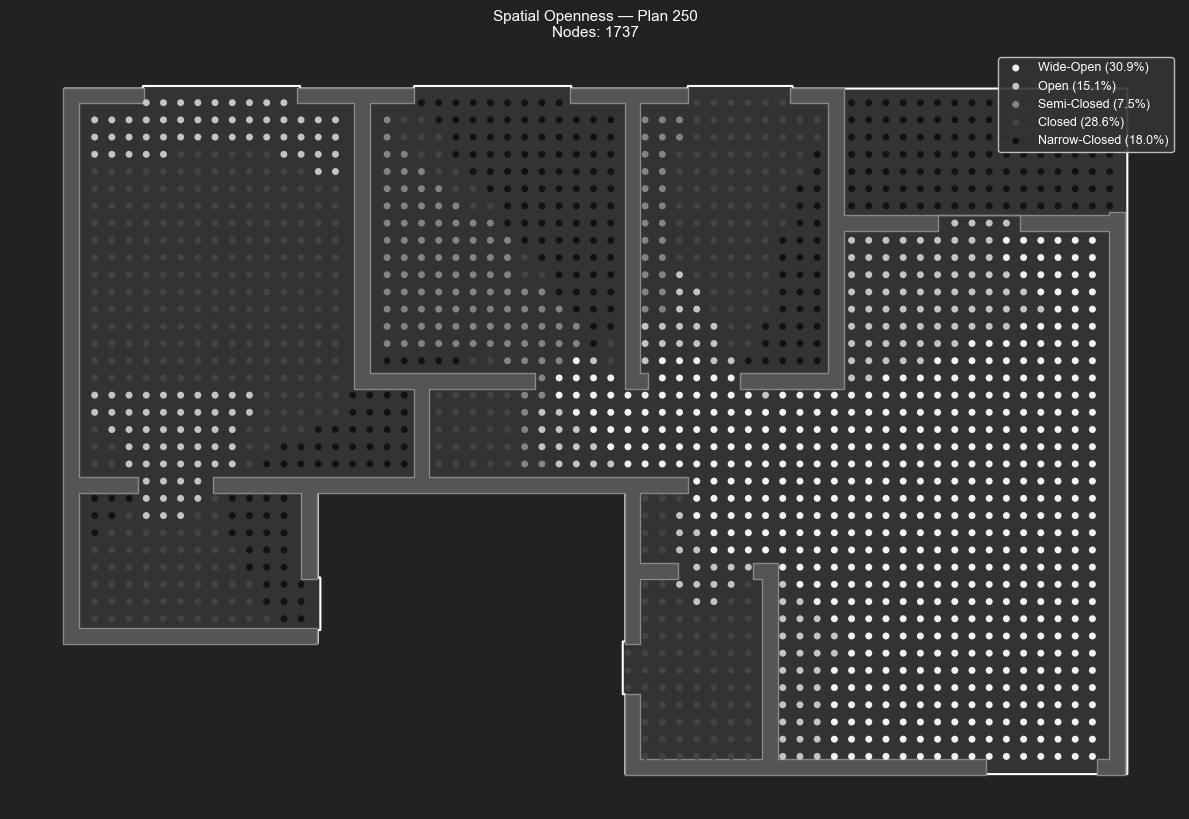

In [5]:
import os, math, joblib, pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from shapely.geometry import MultiPolygon
from shapely.validation import make_valid
from shapely.ops import triangulate
from sklearn.preprocessing import MinMaxScaler
from topologicpy.Face import Face
from topologicpy.Cluster import Cluster
from topologicpy.Vertex import Vertex
from topologicpy.Wire import Wire
from topologicpy.Edge import Edge
from topologicpy.Grid import Grid

EPS = 1e-9

# --- SETTINGS ---
DATASET_PATH  = r"D:\Architecture\cardiff\Algorithmic Thinking\floorplans\ResPlan\ResPlan.pkl"
MODELS_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\Final Files\pipeline_outputs"
plan_idx      = 250

order = ['Wide-Open', 'Open', 'Semi-Closed', 'Closed', 'Narrow-Closed']
FEATURES = ['Av', 'Uv', 'Cv', 'Ov', 'Hv'] 

quality_map = {'Wide-Open': 1.0, 'Open': 0.75, 'Semi-Closed': 0.5, 'Closed': 0.25, 'Narrow-Closed': 0.0}
type_to_color = {'Wide-Open': '#ffffff', 'Open': '#cccccc', 'Semi-Closed': '#888888', 'Closed': '#444444', 'Narrow-Closed': '#111111'}

# --- STEP 1: LOAD ---
with open(DATASET_PATH, "rb") as f:
    dataset = pickle.load(f)

rf_model      = joblib.load(os.path.join(MODELS_FOLDER, "trained_rf_model.joblib"))
global_scaler = joblib.load(os.path.join(MODELS_FOLDER, "data_scaler.joblib"))

plan = dataset[plan_idx]
print(f"Plan {plan_idx} | {plan['unitType']} | {plan['area']:.1f} m²")

# --- GEOMETRY HELPER FUNCTIONS ---
def make_wire(coords):
    if len(coords) < 3: return None
    n = len(coords)
    edges = [Edge.ByVertices([Vertex.ByCoordinates(float(coords[i][0]), float(coords[i][1]), 0.0), Vertex.ByCoordinates(float(coords[(i+1)%n][0]), float(coords[(i+1)%n][1]), 0.0)]) for i in range(n)]
    edges = [e for e in edges if e]
    return Wire.ByEdges(edges) if len(edges) >= 3 else None

def converter(geom):
    geom  = make_valid(geom).simplify(0.1, preserve_topology=True)
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    faces = []
    for poly in polys:
        outer = make_wire(list(poly.exterior.coords)[:-1])
        if outer:
            inner = [w for w in [make_wire(list(h.coords)[:-1]) for h in poly.interiors] if w]
            face  = Face.ByWires(outer, inner) if inner else Face.ByWire(outer)
            if face: faces.append(face); continue
        for tri in triangulate(poly, tolerance=0.01):
            if not poly.contains(tri.centroid): continue
            w = make_wire(list(tri.exterior.coords)[:-1])
            if w:
                f = Face.ByWire(w)
                if f: faces.append(f)
    return faces

def get_segments(geom):
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    segs  = []
    for p in polys:
        c = list(p.exterior.coords)[:-1]; n = len(c)
        segs += [(c[i], c[(i+1)%n]) for i in range(n)]
    return segs

def isovist(pt, walls):
    angles = set()
    for s, e in walls:
        for c in (s, e):
            a = math.atan2(c[1]-pt[1], c[0]-pt[0])
            for d in (-1e-4, 0, 1e-4): angles.add(a+d)
    def hit(a):
        dx, dy = math.cos(a), math.sin(a)
        dists  = []
        for (sx,sy),(ex,ey) in walls:
            wx,wy = ex-sx,ey-sy; det = dx*wy-dy*wx
            if abs(det) < EPS: continue
            fx,fy = sx-pt[0],sy-pt[1]
            t=(fx*wy-fy*wx)/det; u=(fx*dy-fy*dx)/det
            if t > -EPS and -EPS < u < 1+EPS: dists.append(max(t,0))
        return min(dists) if dists else None
    iso = []
    for a in sorted(angles):
        t = hit(a)
        if t is not None: iso.append((pt[0]+t*math.cos(a), pt[1]+t*math.sin(a)))
    clean = []
    for v in iso:
        if not clean or math.hypot(v[0]-clean[-1][0],v[1]-clean[-1][1]) > 1e-6: clean.append(v)
    return clean

def compute_scores(pt, iso, walls):
    n  = len(iso)
    dl = lambda i: math.hypot(iso[i][0]-iso[(i+1)%n][0], iso[i][1]-iso[(i+1)%n][1])
    Av = abs(sum(iso[i][0]*iso[(i+1)%n][1]-iso[(i+1)%n][0]*iso[i][1] for i in range(n))) / 2
    Pv = sum(dl(i) for i in range(n))
    def on_wall(i):
        a,b = iso[i],iso[(i+1)%n]; mid=((a[0]+b[0])/2,(a[1]+b[1])/2)
        for (sx,sy),(ex,ey) in walls:
            wx,wy=ex-sx,ey-sy; sl2=wx**2+wy**2
            if sl2<EPS or abs(wx*(mid[1]-sy)-wy*(mid[0]-sx))>0.01: continue
            t=((mid[0]-sx)*wx+(mid[1]-sy)*wy)/sl2
            if -EPS<=t<=1+EPS: return True
        return False
    occ=sum(dl(i) for i in range(n) if not on_wall(i))
    Uv=Pv-occ; Cv=(4*math.pi*Av/Pv**2) if Pv>EPS else 0
    Ov=occ/Pv if Pv>EPS else 0
    Hv=max(math.hypot(v[0]-pt[0],v[1]-pt[1]) for v in iso)
    return {k:round(v,3) for k,v in dict(Av=Av,Uv=Uv,Cv=Cv,Ov=Ov,Hv=Hv).items()}

# --- BUILD GRID ---
walkable = plan['land'].difference(plan['wall'])
minx,miny,maxx,maxy = walkable.bounds
spacing = min(maxx-minx, maxy-miny) / 40
walkable_shrunk = walkable.buffer(-spacing * 0.1)
walkable_faces = converter(walkable_shrunk)

cx,cy = minx+(maxx-minx)/2, miny+(maxy-miny)/2
origin = Vertex.ByCoordinates(cx, cy, 0.0)
u_range = list(np.arange(-(maxx-minx)/2, (maxx-minx)/2+spacing, spacing))
v_range = list(np.arange(-(maxy-miny)/2, (maxy-miny)/2+spacing, spacing))

vertex_list = []
for face in walkable_faces:
    grid = Grid.VerticesByDistances(face=face, origin=origin, uRange=u_range, vRange=v_range, clip=True, silent=True)
    if grid: vertex_list.extend(Cluster.Vertices(grid))

walls = get_segments(plan['land']) + get_segments(plan['wall'])
node_data = []
for i, vertex in enumerate(vertex_list):
    pt = (Vertex.X(vertex), Vertex.Y(vertex))
    iso = isovist(pt, walls)
    if len(iso) < 3: continue
    s = compute_scores(pt, iso, walls)
    s['x'] = pt[0]; s['y'] = pt[1]
    node_data.append(s)

df = pd.DataFrame(node_data).dropna()
print(f"{len(df)} nodes scored ✅")

# --- STEP 5: INFERENCE PIPELINE ---
# Local Scaling
plan_scaler = MinMaxScaler()
df_local_scaled = plan_scaler.fit_transform(df[FEATURES])
df_local_df = pd.DataFrame(df_local_scaled, columns=FEATURES)

# Global Scaling
X_scaled = global_scaler.transform(df_local_df)

# Apply Weights
LIT_WEIGHTS = {"Av": 1.0, "Uv": 1.0, "Cv": 0.5, "Ov": -0.6, "Hv": 1.0}
weights_array = np.array([LIT_WEIGHTS[f] for f in FEATURES])
X_final = X_scaled * weights_array

# Predict
df['spatial_type'] = rf_model.predict(X_final)
probabilities = rf_model.predict_proba(X_final)

quality_scores = []
for i in range(len(probabilities)):
    node_score = sum(probabilities[i][j] * quality_map[cat] for j, cat in enumerate(rf_model.classes_))
    quality_scores.append(node_score * 100)
df['quality_score'] = quality_scores

# Standard KNN Smoothing (Safe radius to preserve corners)
tree = cKDTree(df[['x','y']].values)
smooth_labels = df['spatial_type'].copy()
for i, row in df.iterrows():
    nbrs = tree.query_ball_point([row['x'], row['y']], r=spacing * 1.2)
    if nbrs:
        smooth_labels.iloc[i] = df['spatial_type'].iloc[nbrs].value_counts().index[0]
df['spatial_type'] = smooth_labels

# --- STEP 6 & 7: REPORT & PLOT ---
counts = df['spatial_type'].value_counts()
total = len(df)
pcts = {l: round(counts.get(l,0)/total*100,1) for l in order}

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('#222222')
fig.patch.set_facecolor('#222222')

gpd.GeoSeries([plan['land']]).plot(ax=ax, color='#333333', edgecolor='white', linewidth=1.5, zorder=1)
gpd.GeoSeries([plan['wall']]).plot(ax=ax, color='#555555', edgecolor='#888888', linewidth=1, zorder=2)

for stype, color in type_to_color.items():
    mask = df['spatial_type'] == stype
    if mask.sum() == 0: continue
    ax.scatter(df[mask]['x'], df[mask]['y'], c=color, s=25, alpha=0.95, zorder=3, edgecolors='none', label=f"{stype} ({pcts[stype]}%)")

ax.legend(loc='upper right', facecolor='#333333', labelcolor='white', fontsize=9, framealpha=0.9)
ax.set_title(f"Spatial Openness — Plan {plan_idx}\nNodes: {total}", color='white', fontsize=11, pad=10)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

Plan 250 | Apartment | 103.1 m²


c:\Users\taha4\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Generating Engineered Topological Exposure Map...


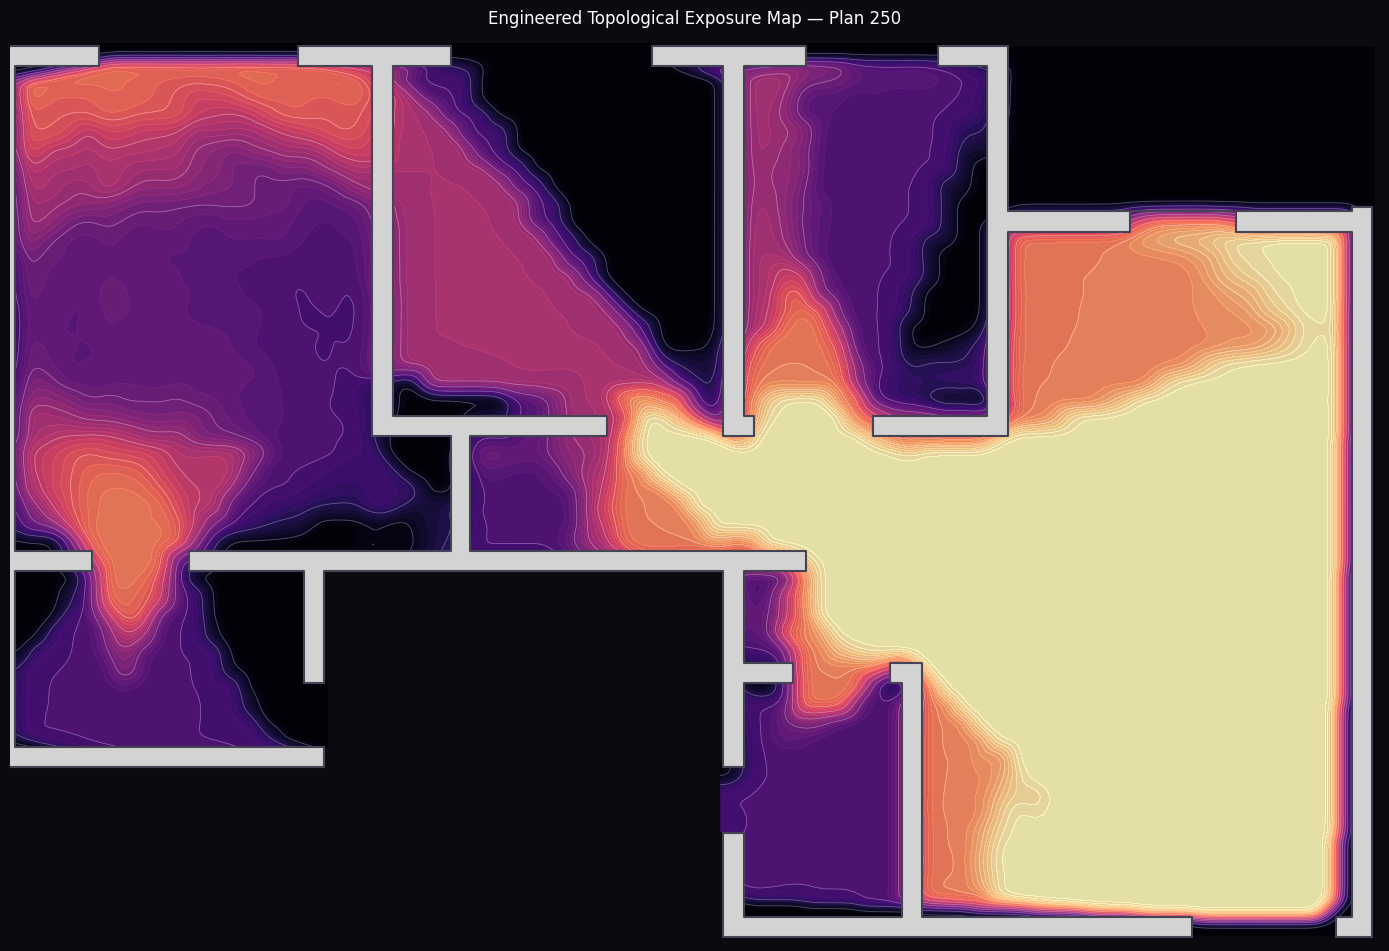

In [9]:
import os, math, joblib, pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
import scipy.ndimage as ndimage
from shapely.geometry import MultiPolygon, box
from shapely.validation import make_valid
from shapely.ops import triangulate
from sklearn.preprocessing import MinMaxScaler
from topologicpy.Face import Face
from topologicpy.Cluster import Cluster
from topologicpy.Vertex import Vertex
from topologicpy.Wire import Wire
from topologicpy.Edge import Edge
from topologicpy.Grid import Grid

EPS = 1e-9

# SETTINGS
DATASET_PATH  = r"D:\Architecture\cardiff\Algorithmic Thinking\floorplans\ResPlan\ResPlan.pkl"
MODELS_FOLDER = r"D:\Architecture\cardiff\Algorithmic Thinking\CAPSTONE\Manifest\Final Files\pipeline_outputs"
plan_idx      = 250

FEATURES = ['Av', 'Uv', 'Cv', 'Ov', 'Hv'] 
order = ['Narrow-Closed', 'Closed', 'Semi-Closed', 'Open', 'Wide-Open']

# Ranks for arrow logic (0 is darkest, 4 is brightest)
rank_map = {'Narrow-Closed': 0, 'Closed': 1, 'Semi-Closed': 2, 'Open': 3, 'Wide-Open': 4}
quality_map = {'Wide-Open': 1.0, 'Open': 0.75, 'Semi-Closed': 0.5, 'Closed': 0.25, 'Narrow-Closed': 0.0}

# LOAD MODELS
with open(DATASET_PATH, "rb") as f: dataset = pickle.load(f)
rf_model      = joblib.load(os.path.join(MODELS_FOLDER, "trained_rf_model.joblib"))
global_scaler = joblib.load(os.path.join(MODELS_FOLDER, "data_scaler.joblib"))

plan = dataset[plan_idx]
print(f"Plan {plan_idx} | {plan['unitType']} | {plan['area']:.1f} m²")

# GEOMETRY FUNCTIONS 
def make_wire(coords):
    if len(coords) < 3: return None
    edges = [Edge.ByVertices([Vertex.ByCoordinates(float(coords[i][0]), float(coords[i][1]), 0.0), Vertex.ByCoordinates(float(coords[(i+1)%len(coords)][0]), float(coords[(i+1)%len(coords)][1]), 0.0)]) for i in range(len(coords))]
    return Wire.ByEdges([e for e in edges if e]) if len([e for e in edges if e]) >= 3 else None

def converter(geom):
    geom  = make_valid(geom).simplify(0.1, preserve_topology=True)
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    faces = []
    for poly in polys:
        outer = make_wire(list(poly.exterior.coords)[:-1])
        if outer:
            inner = [w for w in [make_wire(list(h.coords)[:-1]) for h in poly.interiors] if w]
            face  = Face.ByWires(outer, inner) if inner else Face.ByWire(outer)
            if face: faces.append(face); continue
        for tri in triangulate(poly, tolerance=0.01):
            if not poly.contains(tri.centroid): continue
            w = make_wire(list(tri.exterior.coords)[:-1])
            if w: faces.append(Face.ByWire(w))
    return [f for f in faces if f]

def get_segments(geom):
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    segs  = []
    for p in polys:
        c = list(p.exterior.coords)[:-1]
        segs += [(c[i], c[(i+1)%len(c)]) for i in range(len(c))]
    return segs

def isovist(pt, walls):
    angles = set()
    for s, e in walls:
        for c in (s, e):
            a = math.atan2(c[1]-pt[1], c[0]-pt[0])
            for d in (-1e-4, 0, 1e-4): angles.add(a+d)
    def hit(a):
        dx, dy = math.cos(a), math.sin(a)
        dists  = []
        for (sx,sy),(ex,ey) in walls:
            wx,wy = ex-sx,ey-sy; det = dx*wy-dy*wx
            if abs(det) < EPS: continue
            fx,fy = sx-pt[0],sy-pt[1]
            t=(fx*wy-fy*wx)/det; u=(fx*dy-fy*dx)/det
            if t > -EPS and -EPS < u < 1+EPS: dists.append(max(t,0))
        return min(dists) if dists else None
    iso = []
    for a in sorted(angles):
        t = hit(a)
        if t is not None: iso.append((pt[0]+t*math.cos(a), pt[1]+t*math.sin(a)))
    return [v for i, v in enumerate(iso) if i == 0 or math.hypot(v[0]-iso[i-1][0],v[1]-iso[i-1][1]) > 1e-6]

def compute_scores(pt, iso, walls):
    n = len(iso)
    dl = lambda i: math.hypot(iso[i][0]-iso[(i+1)%n][0], iso[i][1]-iso[(i+1)%n][1])
    Av = abs(sum(iso[i][0]*iso[(i+1)%n][1]-iso[(i+1)%n][0]*iso[i][1] for i in range(n))) / 2
    Pv = sum(dl(i) for i in range(n))
    def on_wall(i):
        a,b = iso[i],iso[(i+1)%n]; mid=((a[0]+b[0])/2,(a[1]+b[1])/2)
        for (sx,sy),(ex,ey) in walls:
            wx,wy=ex-sx,ey-sy; sl2=wx**2+wy**2
            if sl2<EPS or abs(wx*(mid[1]-sy)-wy*(mid[0]-sx))>0.01: continue
            t=((mid[0]-sx)*wx+(mid[1]-sy)*wy)/sl2
            if -EPS<=t<=1+EPS: return True
        return False
    occ=sum(dl(i) for i in range(n) if not on_wall(i))
    Uv=Pv-occ; Cv=(4*math.pi*Av/Pv**2) if Pv>EPS else 0
    Ov=occ/Pv if Pv>EPS else 0
    Hv=max(math.hypot(v[0]-pt[0],v[1]-pt[1]) for v in iso)
    return {k:round(v,3) for k,v in dict(Av=Av,Uv=Uv,Cv=Cv,Ov=Ov,Hv=Hv).items()}

walkable = plan['land'].difference(plan['wall'])
minx, miny, maxx, maxy = walkable.bounds
spacing = min(maxx-minx, maxy-miny) / 50 
walkable_shrunk = walkable.buffer(-spacing * 0.1)

cx, cy = minx+(maxx-minx)/2, miny+(maxy-miny)/2
origin = Vertex.ByCoordinates(cx, cy, 0.0)
u_range = list(np.arange(-(maxx-minx)/2, (maxx-minx)/2+spacing, spacing))
v_range = list(np.arange(-(maxy-miny)/2, (maxy-miny)/2+spacing, spacing))

vertex_list = []
for face in converter(walkable_shrunk):
    grid = Grid.VerticesByDistances(face=face, origin=origin, uRange=u_range, vRange=v_range, clip=True, silent=True)
    if grid: vertex_list.extend(Cluster.Vertices(grid))

walls = get_segments(plan['land']) + get_segments(plan['wall'])
node_data = []
for i, vertex in enumerate(vertex_list):
    pt = (Vertex.X(vertex), Vertex.Y(vertex))
    iso = isovist(pt, walls)
    if len(iso) < 3: continue
    s = compute_scores(pt, iso, walls)
    s['x'] = pt[0]; s['y'] = pt[1]
    node_data.append(s)

df = pd.DataFrame(node_data).dropna()

# ML PREDICTION 
plan_scaler = MinMaxScaler()
X_scaled = global_scaler.transform(plan_scaler.fit_transform(df[FEATURES]))
weights_array = np.array([{"Av": 1.0, "Uv": 1.0, "Cv": 0.5, "Ov": -0.6, "Hv": 1.0}[f] for f in FEATURES])
X_final = X_scaled * weights_array

df['spatial_type'] = rf_model.predict(X_final)
df['rank'] = df['spatial_type'].map(rank_map)

probabilities = rf_model.predict_proba(X_final)
df['quality_score'] = [sum(probabilities[i][j] * quality_map[cat] for j, cat in enumerate(rf_model.classes_)) * 100 for i in range(len(probabilities))]

# Smart Smoothing
tree = cKDTree(df[['x','y']].values)
smooth_labels = df['spatial_type'].copy()
confidence = np.max(probabilities, axis=1)
uncertain_mask = confidence < 0.65 

for i in range(len(df)):
    if uncertain_mask[i]: 
        nbrs = tree.query_ball_point([df.iloc[i]['x'], df.iloc[i]['y']], r=spacing * 1.2)
        confident_nbrs = [n for n in nbrs if confidence[n] >= 0.65]
        if confident_nbrs:
            smooth_labels.iloc[i] = df['spatial_type'].iloc[confident_nbrs].value_counts().index[0]

df['spatial_type'] = smooth_labels
df['rank'] = df['spatial_type'].map(rank_map)


# STEP 6 — THE ENGINEERED TOPOLOGICAL MAP
print("Generating Engineered Topological Exposure Map...")

fig, ax = plt.subplots(figsize=(14, 14))
DARK_BG = '#0a0a0f'
ax.set_facecolor(DARK_BG)
fig.patch.set_facecolor(DARK_BG)

# 1. Create the Math Grid
grid_x, grid_y = np.mgrid[minx:maxx:400j, miny:maxy:400j]
grid_z = griddata((df['x'], df['y']), df['quality_score'], (grid_x, grid_y), method='linear')

# 2. ACCURACY FIX: Light blur just to remove pixelation, keeping the AI's math true
grid_z_smooth = ndimage.gaussian_filter(np.nan_to_num(grid_z, nan=0.0), sigma=2.5)

# 3. ENGINEERED CONTOURS: We draw a line exactly every 10 points of Quality Score (10, 20, 30... 90)
levels = np.arange(5, 100, 10)

# Filled Color Wash
ax.contourf(grid_x, grid_y, grid_z_smooth, levels=40, cmap='magma', alpha=0.9, zorder=1)
# Engineered Mathematical Contour Lines
ax.contour(grid_x, grid_y, grid_z_smooth, levels=levels, colors='white', alpha=0.3, linewidths=0.6, zorder=2)

# 4. Mask the Outside Area
bounding_box = box(minx - 2, miny - 2, maxx + 2, maxy + 2)
gpd.GeoSeries([bounding_box.difference(walkable)]).plot(ax=ax, color=DARK_BG, zorder=3)
gpd.GeoSeries([plan['wall']]).plot(ax=ax, color='#D3D3D3', edgecolor='#444455', linewidth=1.5, zorder=4)

# 5. GRADIENT FLOW ARROWS (Physics-based pathfinding)
# Calculate the slope (gradient) of the smooth topography
v, u = np.gradient(grid_z_smooth)



ax.set_title(f"Engineered Topological Exposure Map — Plan {plan_idx}", color='white', fontsize=12, pad=10)
ax.set_aspect('equal')
ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)
ax.axis('off')
plt.tight_layout()
plt.show()